https://www.perplexity.ai/search/c7c67e8b-1075-40c1-ab9e-69b6324a8954

In [4]:
!pip install yfinance

In [5]:
import yfinance as yf
ticker = '2330.TW'  # 台灣50 ETF
start_date = '2024-01-01'
end_date = '2024-06-01'

data = yf.download(ticker, start=start_date, end=end_date, interval='1d',auto_adjust=False)
data['Adj Close']['2330.TW']

[*********************100%***********************]  1 of 1 completed


Date
2024-01-02    570.360229
2024-01-03    555.932861
2024-01-04    557.856628
2024-01-05    554.009338
2024-01-08    560.741943
                 ...    
2024-05-27    839.725830
2024-05-28    835.860535
2024-05-29    828.130127
2024-05-30    809.770203
2024-05-31    793.342834
Name: 2330.TW, Length: 98, dtype: float64

In [6]:
from pandas import DataFrame
start_date = '2024-01-01'
end_date = '2025-01-01'

tickers = ['2330.TW', '2303.TW', '2454.TW', '2317.TW']
all_data:dict[str:DataFrame]= {ticker: yf.download(ticker,start=start_date, end=end_date, interval='1d',auto_adjust=False) for ticker in tickers }

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [13]:
import pandas as pd

price_df = pd.DataFrame({key:dataframe['Adj Close'][key] for key,dataframe in all_data.items()})
price_df1 = price_df.rename(columns={'2330.TW':'台積電','2303.TW':'聯電','2454.TW':'聯發科','2317.TW':'鴻海'})
price_df1

,台積電,聯電,聯發科,鴻海
Date,,,,
2024-01-02,570.360229,46.182152,881.073242,98.787247
2024-01-03,555.932922,45.025372,855.925415,98.316833
2024-01-04,557.856506,45.203339,855.556641,97.846420
2024-01-05,554.009277,45.203339,849.103027,97.846420
2024-01-08,560.742004,44.936390,848.181091,95.494339
...,...,...,...,...
2024-12-25,1061.257080,41.378731,1328.683350,179.964066
2024-12-26,1061.257080,41.049957,1338.106812,180.929031
2024-12-27,1066.147583,40.956017,1347.530029,179.964066


In [8]:
price_df1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 242 entries, 2024-01-02 to 2024-12-31
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   台積電     242 non-null    float64
 1   聯電      242 non-null    float64
 2   聯發科     242 non-null    float64
 3   鴻海      242 non-null    float64
dtypes: float64(4)
memory usage: 9.5 KB


In [9]:
price_df1.corr()

,台積電,聯電,聯發科,鴻海
台積電,1.000000,0.124844,0.883301,0.932589
聯電,0.124844,1.000000,0.143217,0.294091
聯發科,0.883301,0.143217,1.000000,0.831721
鴻海,0.932589,0.294091,0.831721,1.000000


In [10]:
import wget
wget.download("https://github.com/roberthsu2003/machine_learning/raw/refs/heads/main/source_data/ChineseFont.ttf")

'ChineseFont.ttf'

In [11]:
import matplotlib as mpl
from matplotlib.font_manager import fontManager

fontManager.addfont("ChineseFont.ttf")
mpl.rc('font', family="ChineseFont")

<Axes: xlabel='Date'>

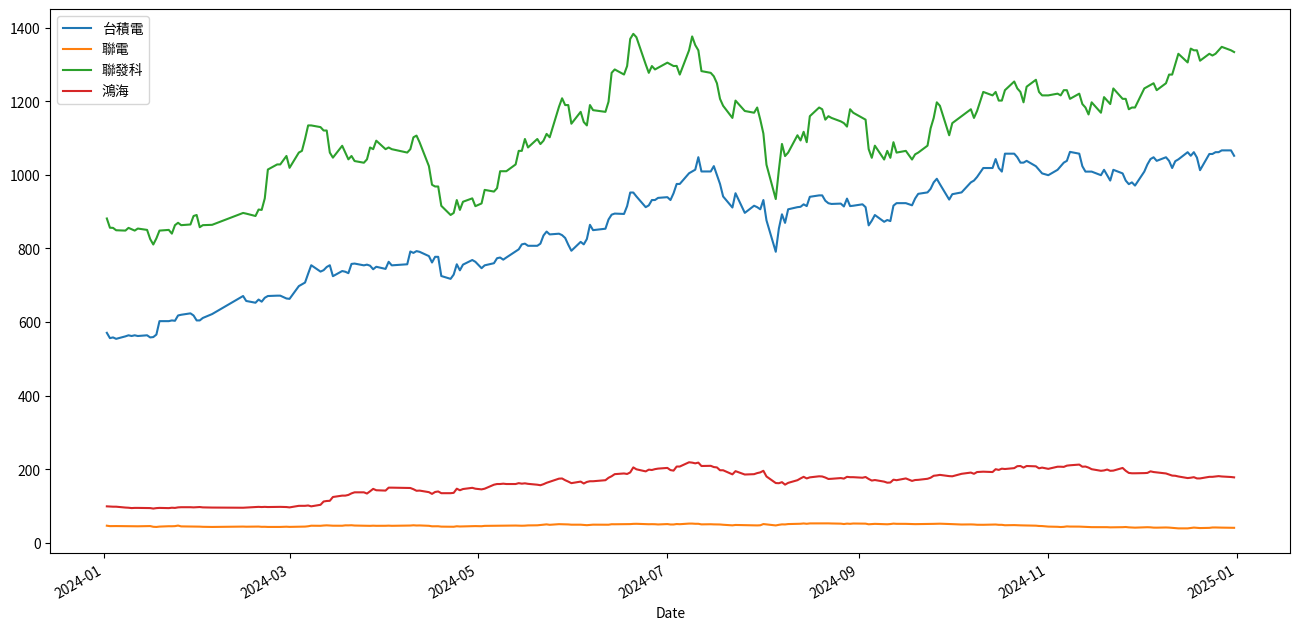

In [12]:
import matplotlib.pyplot as plt
figure = plt.figure(figsize=(16,8))
axes = figure.add_subplot()
price_df1.plot.line(ax=axes)